# Time-of-flight calibration

In [ ]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.experiments.cal01_time_of_flight import TimeOfFlight

## Run parameters

In [ ]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # Use None if no flux bias needed
OUTPUT_DIR = Path("data")

QUBITS = ["q1"]
FREQUENCY_DETUNING = 10e6
PULSE_DURATION = 1e-6
PULSE_AMPLITUDE = 0.05
ACQUISITION_DURATION = 2e-6
ACQUISITION_DELAY = 0.0
REPETITIONS = 100

OUTPUT_ATTENUATION = None
INPUT_ATTENUATION = None
READOUT_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLAYBACK_DELAY = 146e-9
PLOT_RESULTS = True
SAVE_CALIBRATED_DEVICE = CONFIG_DIR / "dut_config_AS_QRC_upd.json"  # Use None if param persisting is not required

## Hardware and experiment

In [ ]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = TimeOfFlight(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
)

atexit.register(Instrument.close_all)

## Measurement

In [9]:
dataset = experiment.run_measurement(
    frequency_detuning=FREQUENCY_DETUNING,
    pulse_duration=PULSE_DURATION,
    pulse_amplitude=PULSE_AMPLITUDE,
    acquisition_duration=ACQUISITION_DURATION,
    acquisition_delay=ACQUISITION_DELAY,
    repetitions=REPETITIONS,
    output_attenuation=OUTPUT_ATTENUATION,
    input_attenuation=INPUT_ATTENUATION,
    readout_lo_frequency=READOUT_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
Exception 'AsyncParameter' object has no attribute 'on_set_callback' in on set callback for cluster_A_module4_sequencer0_sync_en with value False
Traceback (most recent call last):
  File "/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_instruments/qcodes_drivers/async_parameter.py", line 72, in set_wrapper
    if self.on_set_callback is not None:
AttributeError: 'AsyncParameter' object has no attribute 'on_set_callback'
Exception 'AsyncParameter' object has no attribute 'on_set_callback' in on set callback for cluster_A_module4_sequencer1_sync_en with value False
Traceback (most recent call last):
  File "/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_instruments/qcodes_driv

<xarray.Dataset> Size: 48kB
Dimensions:               (trace_index_trace_q1: 2000, acq_index_trace_q1: 1)
Coordinates:
  * trace_index_trace_q1  (trace_index_trace_q1) int64 16kB 0 1 2 ... 1998 1999
  * acq_index_trace_q1    (acq_index_trace_q1) int64 8B 0
Data variables:
    trace_q1              (acq_index_trace_q1, trace_index_trace_q1) complex128 32kB ...
Attributes:
    tuid:     20260817-092412-540-12b4d3

## Analysis

In [10]:
results = experiment.analysis(playback_delay=PLAYBACK_DELAY)
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: time of flight = {result.time_of_flight * 1e9:.0f} ns, "
            f"NCO propagation delay = {result.nco_propagation_delay * 1e9:.0f} ns"
        )
    else:
        print(f"{qubit}: time-of-flight detection failed")

q1: time-of-flight detection failed


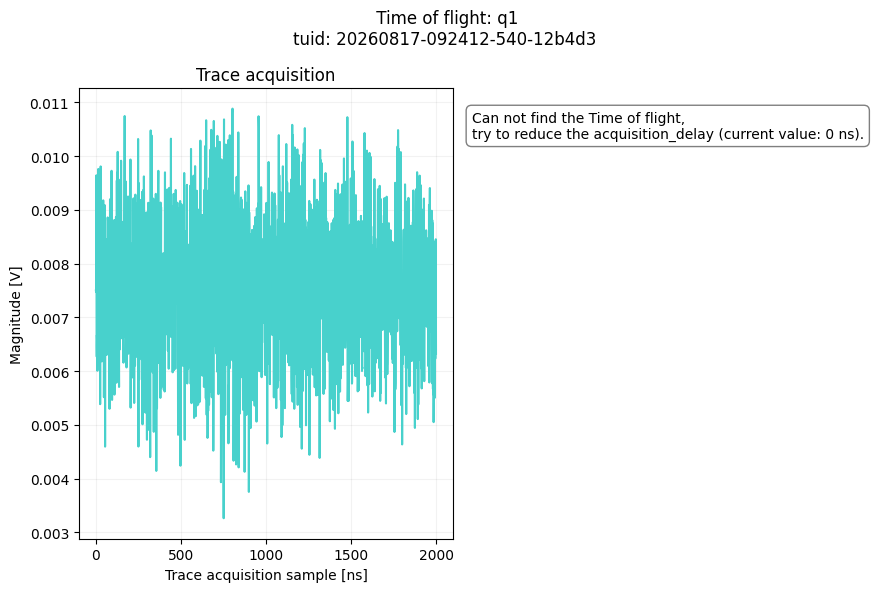

In [11]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [7]:
if SAVE_CALIBRATED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_CALIBRATED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to ..\config\dut_config_upd.json


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()